# Notebook 2 — EDA and Preprocessing
This notebook performs exploratory analysis on the generated raw dataset and then executes the preprocessing pipeline from `src.data.preprocess`. We focus on distributions, correlations, and class balance before/after the split to validate training data quality.

## Imports and raw data load
We load the raw CSV generated in Notebook 1 and set plotting defaults.

The next cell reads `data/raw/sensor_data.csv` and prints shape + preview.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.preprocess import run_pipeline

sns.set_theme(style="whitegrid")
raw_path = project_root / "data" / "raw" / "sensor_data.csv"

df = pd.read_csv(raw_path, parse_dates=["timestamp"])
print("Raw shape:", df.shape)
display(df.head())

Raw shape: (1303205, 9)


,timestamp,machine_id,temperature,vibration,pressure,rpm,current,failure_within_48h,time_to_failure
0,2025-01-01 00:00:00,Machine_1,75.993428,2.315037,4.473360,1491.979085,15.393747,0,NaN
1,2025-01-01 00:01:00,Machine_1,74.723471,2.369734,5.447588,1519.024295,14.430274,0,NaN
2,2025-01-01 00:02:00,Machine_1,76.295377,2.358509,5.134485,1508.074185,14.787605,0,NaN
3,2025-01-01 00:03:00,Machine_1,78.046060,2.452708,4.809742,1481.132193,15.239413,0,NaN
4,2025-01-01 00:04:00,Machine_1,74.531693,2.555839,4.699724,1473.959258,15.047301,0,NaN


## Basic descriptive statistics
We inspect central tendency and spread for all numeric variables.

In [2]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
timestamp,1303205,2025-04-01 12:00:00,2025-01-01 00:00:00,2025-02-15 06:00:00,2025-04-01 12:00:00,2025-05-16 18:00:00,2025-07-01 00:00:00,NaN
temperature,1303205.0,75.860976,63.306218,73.779669,75.210638,76.755966,105.032107,3.880033
vibration,1303205.0,2.629332,1.182129,2.377683,2.521494,2.67803,6.780504,0.538265
pressure,1303205.0,5.086481,3.547463,4.816827,5.030113,5.259564,8.608973,0.448147
rpm,1303205.0,1508.64524,1360.667437,1481.648851,1503.0241,1525.92942,1864.13329,44.844998
current,1303205.0,15.214581,12.201935,14.693323,15.050657,15.439098,22.674006,0.972152
failure_within_48h,1303205.0,0.086188,0.0,0.0,0.0,0.0,1.0,0.280641
time_to_failure,112320.0,24.008333,0.016667,12.0125,24.008333,36.004167,48.0,13.856467


## Sensor distributions by label
The following plots compare each sensor distribution for `failure_within_48h = 0` vs `1`.

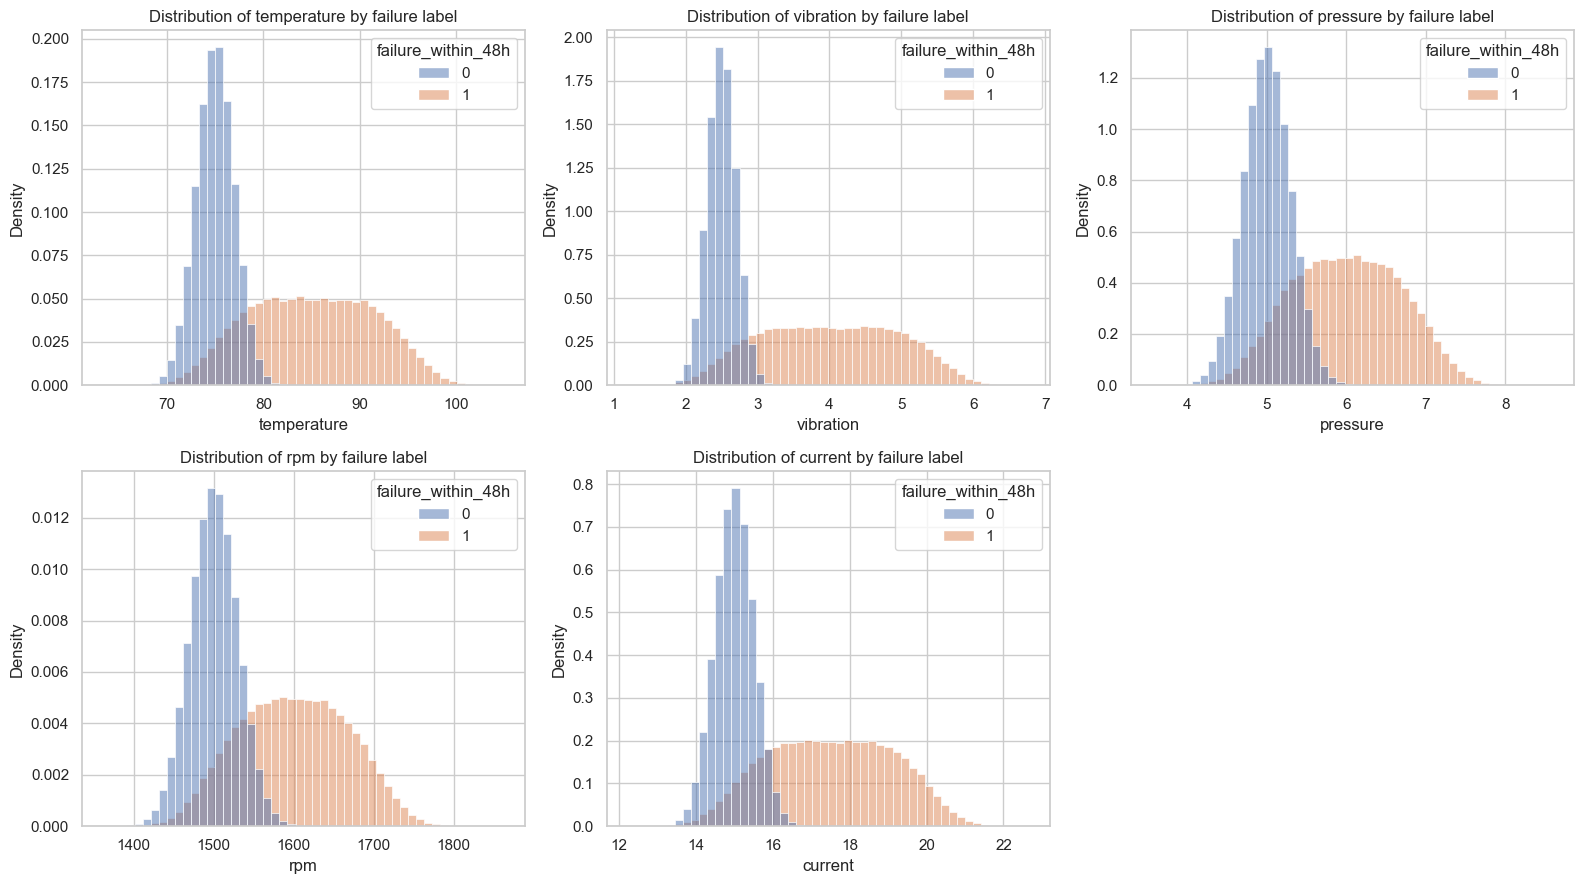

In [3]:
sensors = ["temperature", "vibration", "pressure", "rpm", "current"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    sns.histplot(
        data=df, x=sensor, hue="failure_within_48h",
        stat="density", common_norm=False, bins=50, alpha=0.5, ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {sensor} by failure label")
    axes[i].set_xlabel(sensor)
    axes[i].set_ylabel("Density")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## Correlation heatmap
We inspect pairwise correlations among the five sensors.

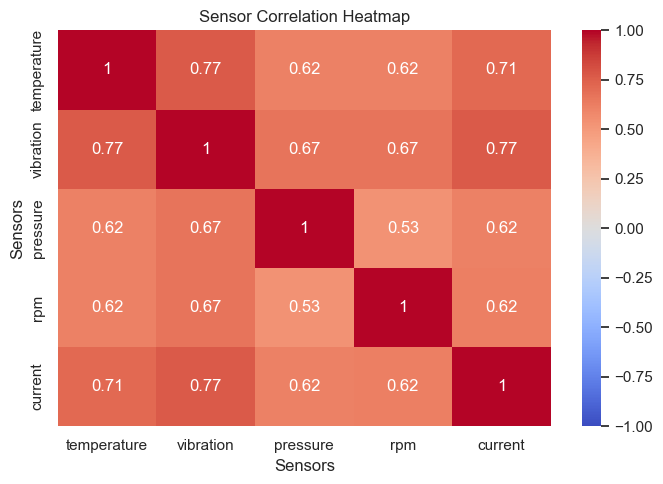

In [4]:
corr = df[["temperature", "vibration", "pressure", "rpm", "current"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Sensor Correlation Heatmap")
plt.xlabel("Sensors")
plt.ylabel("Sensors")
plt.tight_layout()
plt.show()

## Run preprocessing pipeline
We call `run_pipeline()` from `src.data.preprocess` to clean, split, and scale data into train/val/test files.

In [5]:
run_pipeline()

✅ Loaded data: (1303205, 9)


✅ Missing values: 0 → 0


✅ Outliers removed: 74,673 rows → 1,228,532 rows remaining
✅ Split — train: 859,972 | val: 184,280 | test: 184,280


✅ Scaler saved to C:\Users\avarg\OneDrive\Documentos\proyect-PMA\predictive-maintenance-automotive\data\processed\scaler.pkl


✅ Processed splits saved to C:\Users\avarg\OneDrive\Documentos\proyect-PMA\predictive-maintenance-automotive\data\processed


## Split sizes and class balance before/after split
We compare class distribution in the original data and in each generated split.

In [6]:
processed_dir = project_root / "data" / "processed"
train_df = pd.read_csv(processed_dir / "train.csv", parse_dates=["timestamp"])
val_df = pd.read_csv(processed_dir / "val.csv", parse_dates=["timestamp"])
test_df = pd.read_csv(processed_dir / "test.csv", parse_dates=["timestamp"])

print("Train/Val/Test sizes:")
print({"train": len(train_df), "val": len(val_df), "test": len(test_df)})

def balance_table(dataframe, name):
    c = dataframe["failure_within_48h"].value_counts().sort_index()
    p = (c / c.sum() * 100).round(2)
    out = pd.DataFrame({"split": name, "label": c.index, "count": c.values, "percentage": p.values})
    return out

before = balance_table(df, "raw")
after = pd.concat([
    balance_table(train_df, "train"),
    balance_table(val_df, "val"),
    balance_table(test_df, "test")
])

display(before)
display(after)

Train/Val/Test sizes:
{'train': 859972, 'val': 184280, 'test': 184280}


,split,label,count,percentage
0,raw,0,1190885,91.38
1,raw,1,112320,8.62


,split,label,count,percentage
0,train,0,835728,97.18
1,train,1,24244,2.82
0,val,0,176595,95.83
1,val,1,7685,4.17
0,test,0,178561,96.90
1,test,1,5719,3.10


Preprocessing outputs are ready for feature engineering in Notebook 3.